# GCE Models

In [1]:
import math as m

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vice

import paths

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')
mwm_rgb

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_47948/610113364.py:1: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')


,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
0,54381291,NaN,421495278551818624,421495278551818624,403218924,16384,tic_v8,25,27021597850714872,4291430952,...,NaN,0.132960,4.281347,56.316985,14.488654,15.619171,13.432241,1.114031,NaN,NaN
1,54381397,NaN,421505552113500800,421505552113500800,369831391,16384,tic_v8,25,27021597850723334,4291439436,...,NaN,0.229285,4.066874,56.422930,13.574258,14.658734,12.552815,1.032361,NaN,NaN
2,54381405,NaN,421506067509558016,421506067510359808,369831290,16384,tic_v8,25,27021597850724078,4291440182,...,NaN,0.287407,4.092194,56.472699,12.253111,13.457909,11.174816,1.058355,NaN,NaN
3,54381758,2M00204981+5625073,421540152367477248,421540152367477248,403307163,16385,gaia_dr3_source,31,63050394783216344,4291448641,...,NaN,0.137260,5.207570,56.418666,13.690668,14.897005,12.616476,1.025529,NaN,NaN
4,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,0.176938,0.534588,5.671459,56.613157,11.369628,12.251155,10.450673,1.183852,0.205899,8.531358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178300,129060878,2M11484212-6220219,5334808943135705600,5334808943135705600,324668848,185355,gaia_dr3_source,31,63050395882762275,5762936654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178301,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178302,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178303,129060909,2M13582184-6202236,5866253799616922112,5866253799616922112,325588166,185382,gaia_dr3_source,31,63050396108514375,5632820971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
mwm_rgb_local = mwm_rgb[
    (mwm_rgb['gal_r'] >= 7) &
    (mwm_rgb['gal_r'] < 9) &
    (mwm_rgb['gal_z'].abs() < 2)
]
mwm_rgb_local

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
5,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,0.023527,0.821440,5.742822,56.604244,11.354103,12.103177,10.509450,1.051452,0.107297,8.766076
19,54382295,NaN,421589183715747968,421589183715747968,327577724,16024,tic_v8,25,27021597850733418,4291449550,...,0.082842,0.621352,4.838551,56.535746,12.989830,13.689755,12.176354,1.093702,0.253124,8.840263
27,54382700,2M00200721+5700122,421625909974353280,421625914277199872,406762101,15668,gaia_dr3_source,31,63050394783245110,4291624784,...,0.126596,0.953161,5.030085,57.003410,11.962486,12.695877,11.121562,6.407218,0.183795,7.756411
60,54383757,2M00290801+5640111,421706109904337024,421706109904337024,320047050,16027,gaia_dr3_source,31,63050394783273185,4291910754,...,0.098802,0.726696,7.283335,56.669774,12.007926,12.807559,11.132788,4.010105,0.136858,8.739005
73,54384509,2M00271056+5654556,421762352496488832,421762352496488832,319844954,15670,gaia_dr3_source,31,63050394783292573,4291900981,...,0.098081,0.637712,6.794001,56.915434,12.128599,12.845614,11.306450,1.005274,0.154093,8.455453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178281,129060702,2M09103407-4845571,5326025391417031552,5326025391417031552,355665042,172356,gaia_dr3_source,31,63050395875983927,5802300960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178287,129060768,2M09150089-4756448,5326450696258684032,5326450696258684032,461741387,171468,gaia_dr3_source,31,63050395876069826,5802236276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178289,129060777,2M09120875-4832413,5326054081799907712,5326054081799907712,372916511,171914,gaia_dr3_source,31,63050395875989157,5802232075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178298,129060864,2M09093978-4751104,5326886175877017088,5326886175877017088,74380758,171016,gaia_dr3_source,31,63050395876148699,5802260041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
output_dir = paths.data / 'onezone'
output_dir.mkdir(parents=True, exist_ok=True)

## s-process only

In [52]:
vice.yields.ccsne.settings['mg'] = 0.0019
vice.yields.ccsne.settings['fe'] = 0.0012
vice.yields.ccsne.settings['ce'] = 0.
vice.yields.sneia.settings['mg'] = 0.
vice.yields.sneia.settings['fe'] = 0.0024
vice.yields.sneia.settings['ce'] = 0.
from vice.yields.agb import cristallo11

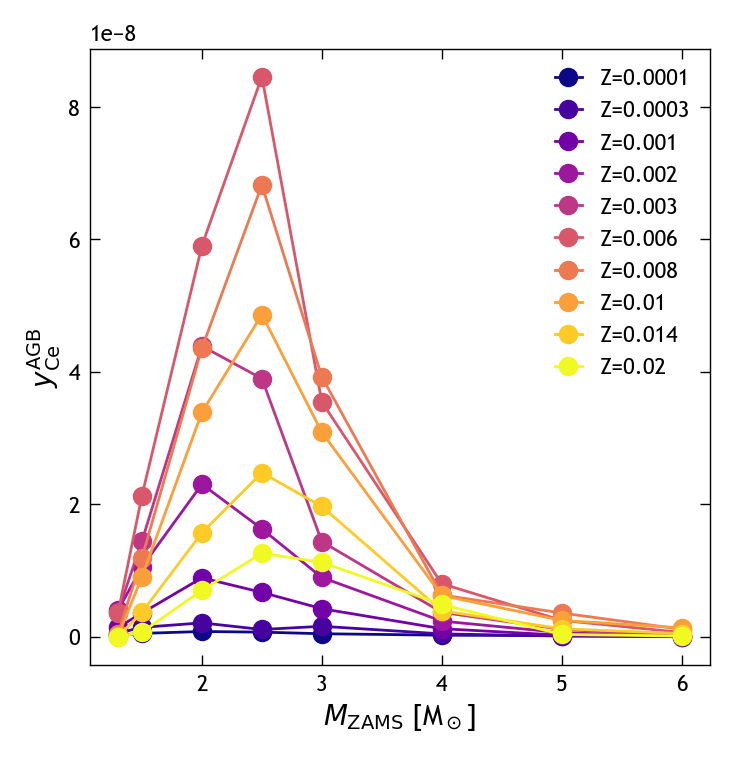

In [53]:
fig, ax = plt.subplots()

grid, masses, metallicities = vice.yields.agb.grid('ce', study='cristallo11')
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(metallicities)))
for i, z in enumerate(metallicities):
    yields = [grid[_][i] for _ in range(len(grid))]
    ax.plot(masses, yields, c=colors[i], marker='o', label=f'Z={z}')
ax.set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
ax.set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
ax.legend()
plt.show()

In [54]:
dt = 0.01
tmax = 13.2
simtime = np.arange(0, tmax+dt, dt)

tau_rise = 2
# timescale = 15
# def sfr(time):
#     return (1 - m.exp(-time / tau_rise)) * m.exp(-time/timescale)

In [55]:
outflows = [1, 2.5, 5]
timescales = [7, 15, 30]
names = ['inner', 'solar', 'outer']

for i, tau_sfh in enumerate(timescales):
    sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-1p-{names[i]}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=outflows[i],
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements track

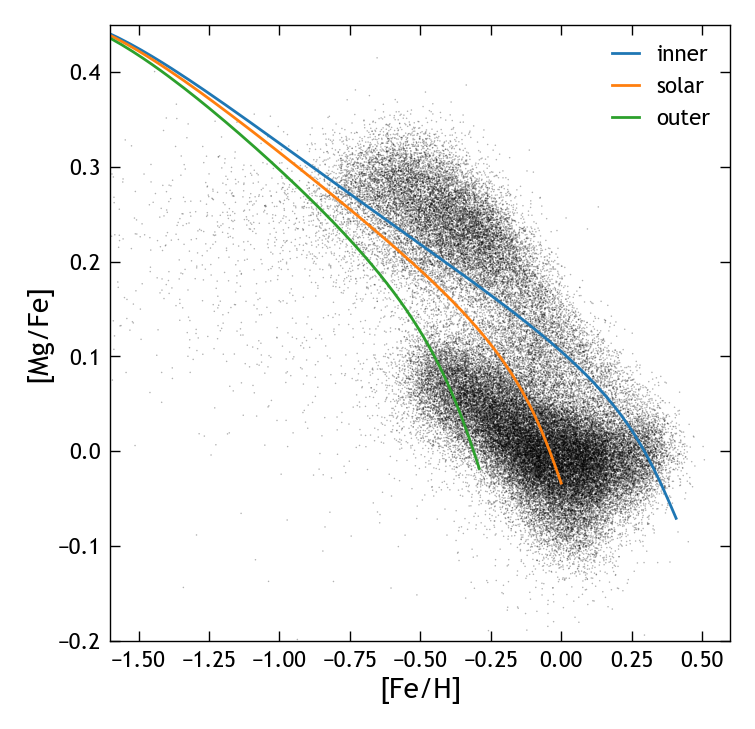

In [56]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['mg_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-1p-{name}'))
    ax.plot(hist['[fe/h]'], hist['[mg/fe]'], label=name)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.set_xlim((-1.6, 0.6))
ax.set_ylim((-0.2, 0.45))
ax.legend()
plt.show()

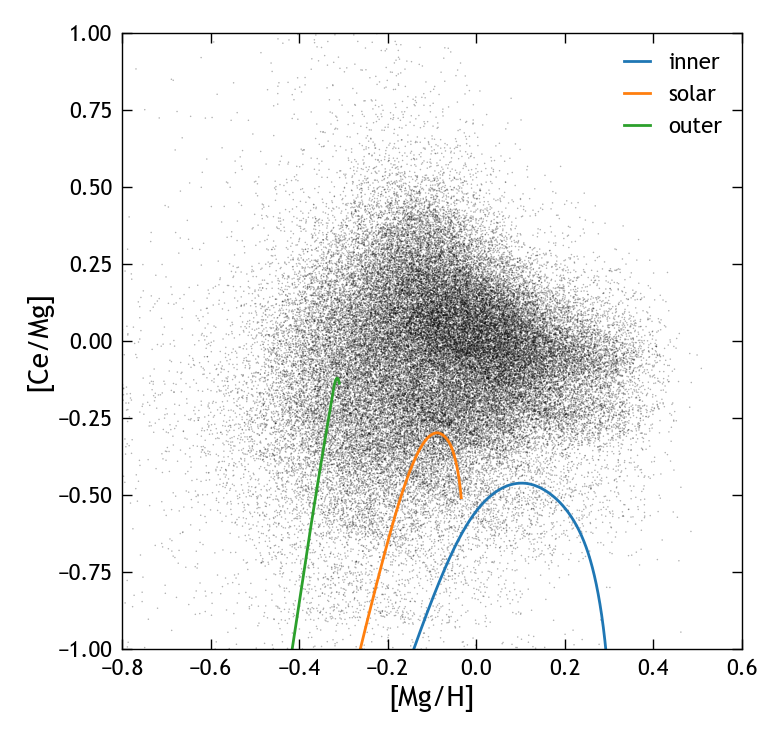

In [57]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-1p-{name}'))
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=name)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
plt.show()

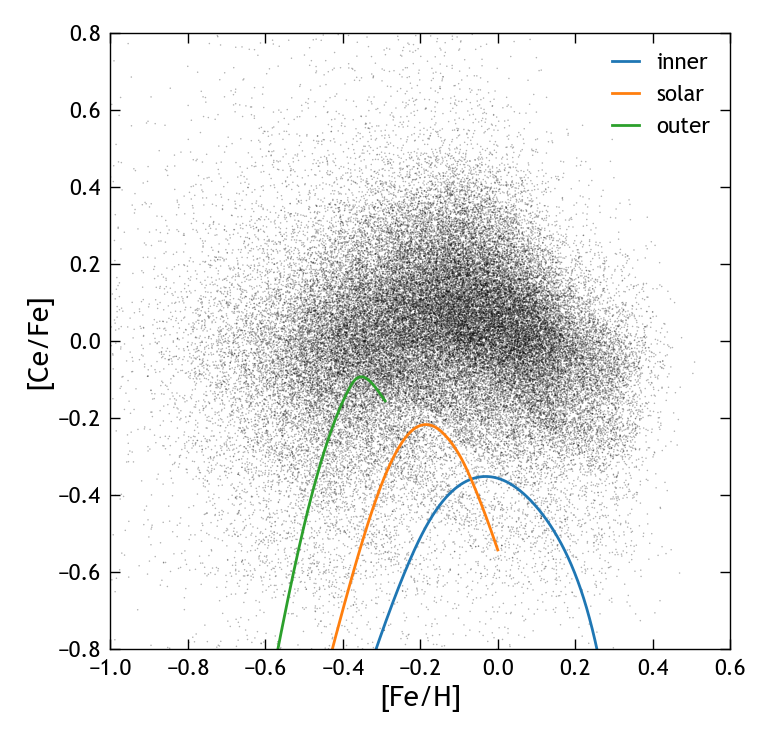

In [58]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-1p-{name}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=name)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-1., 0.6))
ax.set_ylim((-0.8, 0.8))
ax.legend()
plt.show()

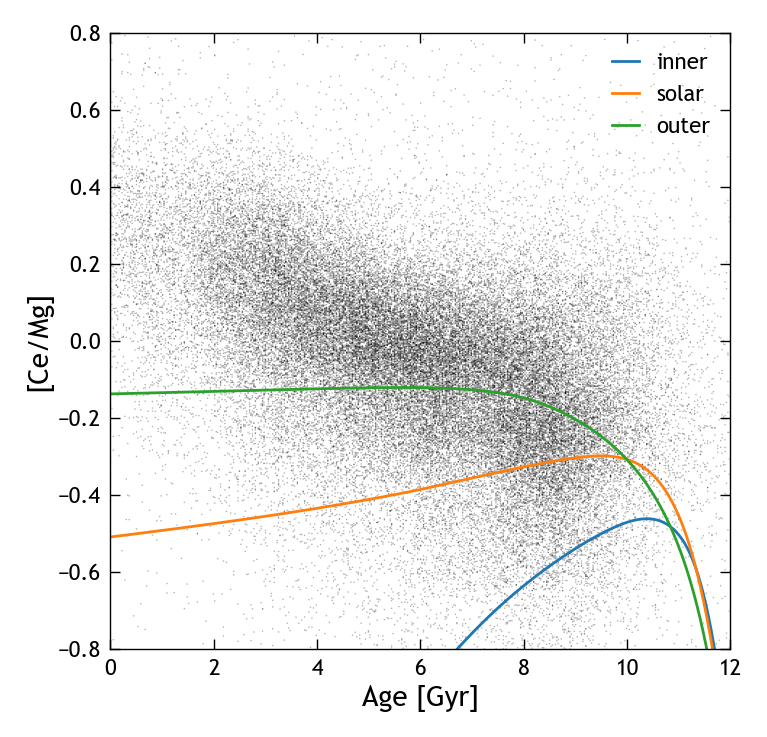

In [69]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-1p-{name}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=name)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
plt.show()

## Prompt r-process

In [59]:
vice.yields.ccsne.settings['ce'] = 3e-9
vice.yields.sneia.settings['ce'] = 0

In [60]:
outflows = [1, 2.5, 5]
timescales = [7, 15, 30]
names = ['inner', 'solar', 'outer']

for i, tau_sfh in enumerate(timescales):
    sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-2p-{names[i]}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=outflows[i],
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements track

[nan, -0.5427773382972958, -0.5427771849574905, -0.5427772413483176, -0.542777293202507, -0.5427772778153821, -0.5427772914880964, -0.5427867237163118, -0.5428004102119137, -0.54281375002007, -0.5428236932426123, -0.5428310987943883, -0.5428387148338527, -0.5428473444406217, -0.5428570817730463, -0.5428678083105758, -0.542878735932275, -0.5428899192561311, -0.5428992123757911, -0.542907055035639, -0.5429120553090139, -0.5429132125822422, -0.5429105953390123, -0.5429036508098677, -0.5428938307106055, -0.542880957573225, -0.5428641908293831, -0.5428427454720934, -0.5428155290049179, -0.5427812724600893, -0.5427389966259489, -0.5426878358948005, -0.5426268216645641, -0.5425551665017538, -0.542472142907311, -0.5423772419609287, -0.5422699356300533, -0.5421496550813812, -0.5420159070774738, -0.5418684705582764, -0.5417073687439272, -0.5415323685265083, -0.5413430661256335, -0.5411389767553039, -0.5409191349089719, -0.5406829555139269, -0.5404300241682987, -0.5401595439210568, -0.53987129470

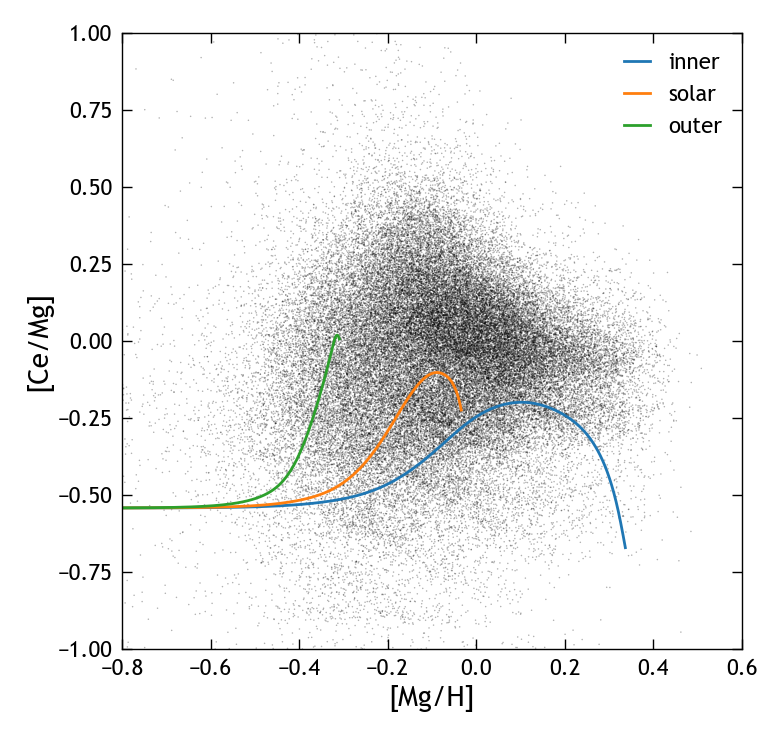

In [61]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-2p-{name}'))
    print(hist['[ce/mg]'])  
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=name)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
plt.show()

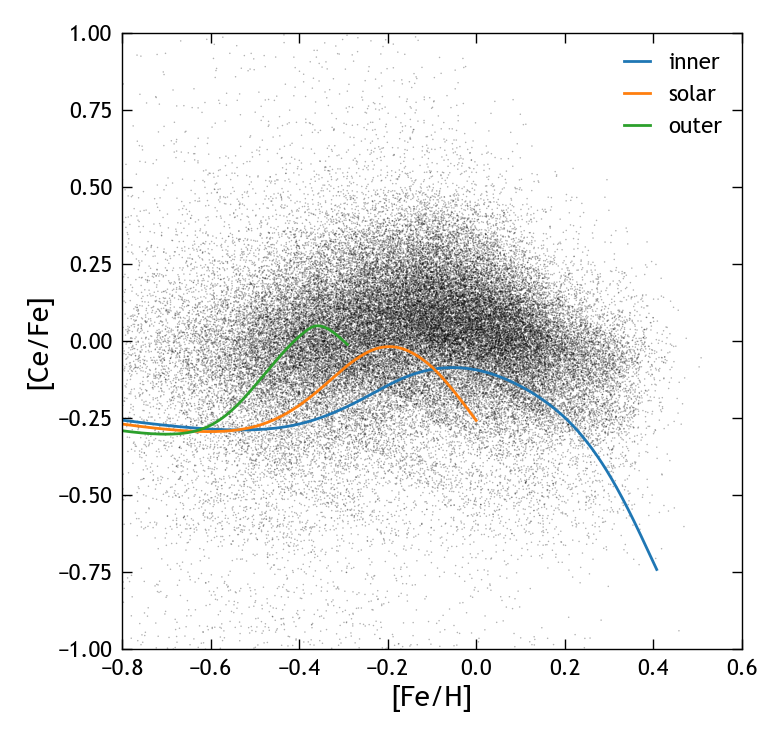

In [62]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-2p-{name}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=name)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
plt.show()

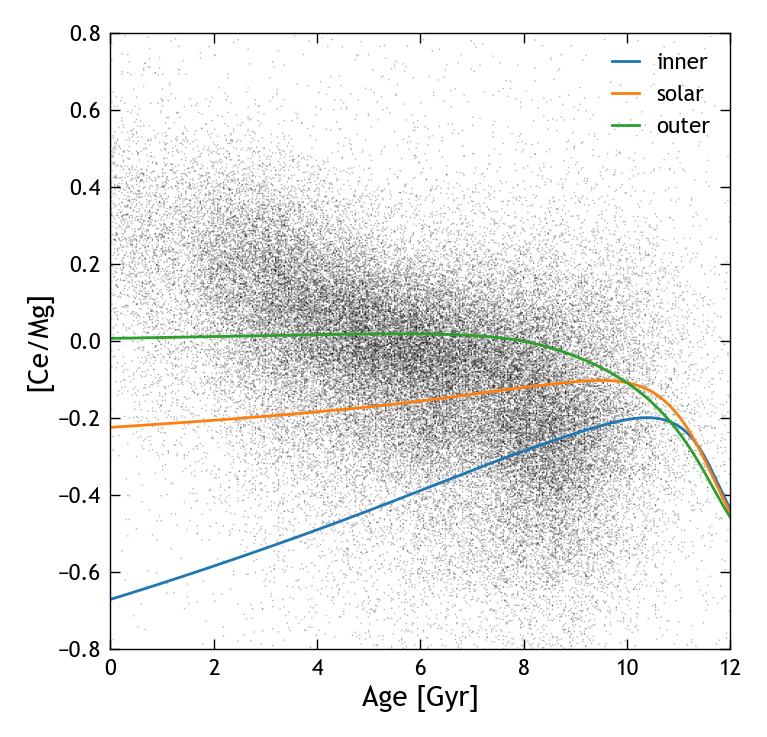

In [70]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-2p-{name}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=name)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
plt.show()

## Pseudo-NSM contribution

In [63]:
vice.yields.ccsne.settings['ce'] = 3e-9
vice.yields.sneia.settings['ce'] = 3e-9

In [64]:
outflows = [1, 2.5, 5]
timescales = [7, 15, 30]
names = ['inner', 'solar', 'outer']

for i, tau_sfh in enumerate(timescales):
    sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-3p-{names[i]}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=outflows[i],
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements track

[nan, -0.5427773382972958, -0.5427771849574905, -0.5427772413483176, -0.542777293202507, -0.5427772778153821, -0.5416226429138391, -0.5395158222927074, -0.5367684390664851, -0.5336268342600832, -0.5302625638685912, -0.5267933394433455, -0.523298378128024, -0.519828025809471, -0.5164142376424214, -0.5130759873166166, -0.5098251649997917, -0.5066674220482633, -0.5036036757276768, -0.5006346656120588, -0.49775798306978425, -0.4949706101398106, -0.49226936109580377, -0.48965099211386987, -0.4871130461124906, -0.48465189102562967, -0.48226338524139123, -0.47994338404552717, -0.47768747261150346, -0.4754916421765756, -0.47335202219991646, -0.47126493129143376, -0.4692268399234537, -0.4672345488638201, -0.46528515032315776, -0.4633758155664962, -0.4615040874982199, -0.45966753653323156, -0.4578636995300377, -0.4560902681456631, -0.45434656520249395, -0.45262993009446717, -0.45093931969585865, -0.44927179152083574, -0.44762638882409833, -0.44600111952816335, -0.44439399262463564, -0.4428038349

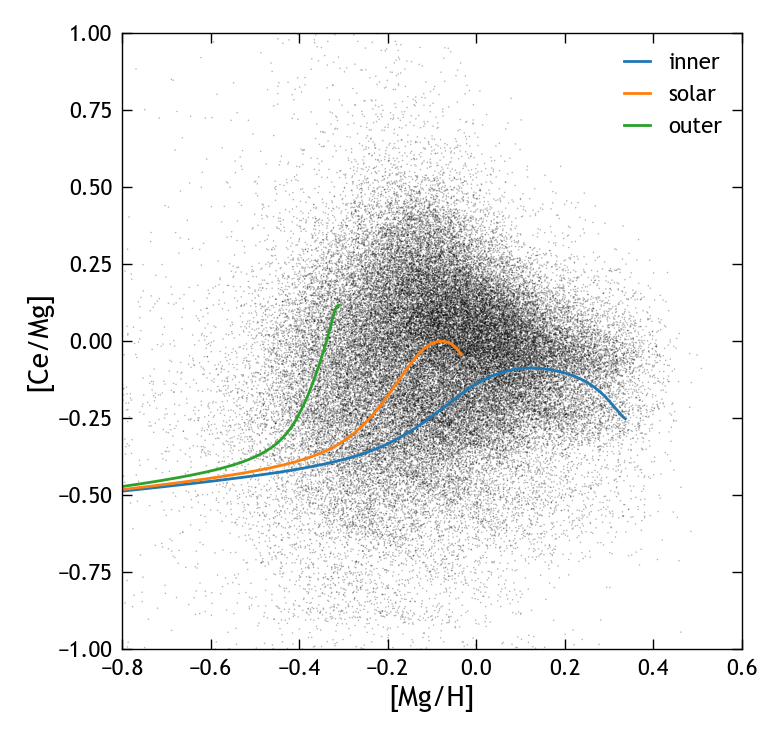

In [65]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-3p-{name}'))
    print(hist['[ce/mg]'])  
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=name)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
plt.show()

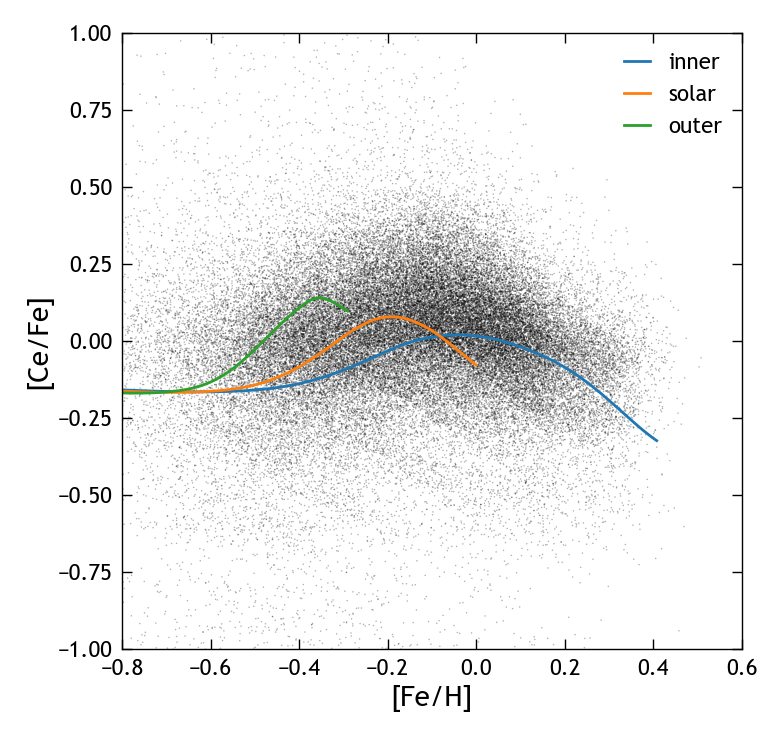

In [66]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-3p-{name}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=name)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
plt.show()

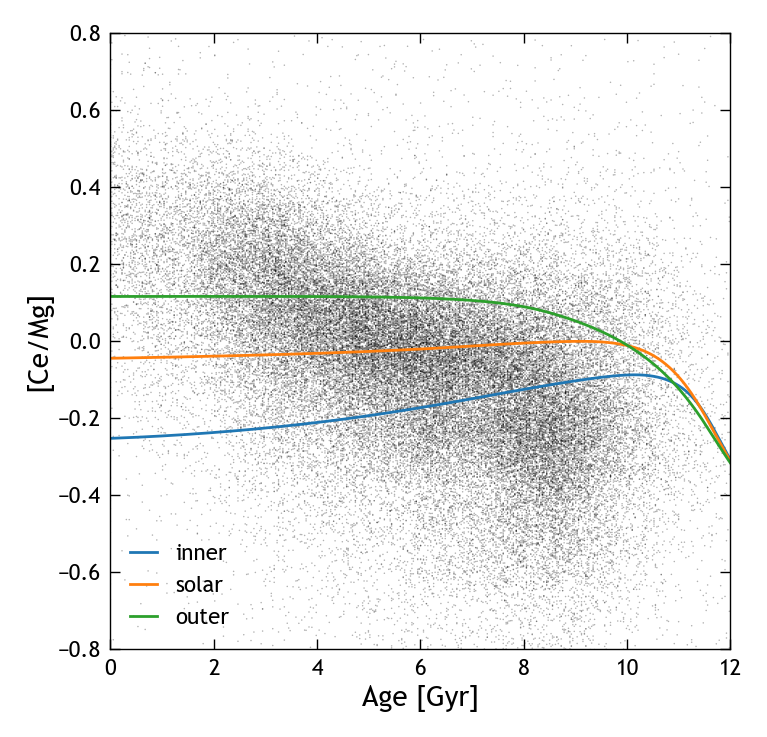

In [71]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, name in enumerate(names):
    hist = vice.history(str(output_dir / f'cerium-3p-{name}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=name)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
plt.show()